# Sentiment Analysis using RNN, LSTM & Bidirectional LSTM
### IMDB Movie Reviews - Binary Sentiment Classification

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, auc
)

from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
import re
import pickle
import os
import warnings

warnings.filterwarnings('ignore')

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

## 2. Load Dataset

In [2]:
VOCAB_SIZE = 20000

(X_train_raw, y_train), (X_test_raw, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

# Word index mapping
word_index = keras.datasets.imdb.get_word_index()
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = '<PAD>'
reverse_word_index[1] = '<START>'
reverse_word_index[2] = '<UNK>'
reverse_word_index[3] = '<UNUSED>'

def decode_review(encoded_review):
    return ' '.join(reverse_word_index.get(idx, '?') for idx in encoded_review)

print(f"Training Samples  : {len(X_train_raw)}")
print(f"Testing Samples   : {len(X_test_raw)}")
print(f"Vocabulary Size   : {VOCAB_SIZE}")
print(f"Training Positive : {sum(y_train)} ({sum(y_train)/len(y_train)*100:.1f}%)")
print(f"Training Negative : {len(y_train)-sum(y_train)} ({(len(y_train)-sum(y_train))/len(y_train)*100:.1f}%)")

Training Samples  : 25000
Testing Samples   : 25000
Vocabulary Size   : 20000
Training Positive : 12500 (50.0%)
Training Negative : 12500 (50.0%)


## 3. Data Exploration & Visualization

In [ ]:
def plot_data_exploration(X_train, y_train, X_test, y_test):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('IMDB Dataset Exploration', fontsize=18, fontweight='bold')

    labels = ['Negative', 'Positive']
    colors = ['red', 'green']

    train_counts = [len(y_train) - sum(y_train), sum(y_train)]
    axes[0][0].bar(labels, train_counts, color=colors, edgecolor='black', width=0.5)
    axes[0][0].set_title('Training Set - Class Distribution', fontsize=13, fontweight='bold')
    axes[0][0].set_ylabel('Count')
    for i, count in enumerate(train_counts):
        axes[0][0].text(i, count + 200, str(count), ha='center', fontsize=12, fontweight='bold')

    test_counts = [len(y_test) - sum(y_test), sum(y_test)]
    axes[0][1].bar(labels, test_counts, color=colors, edgecolor='black', width=0.5)
    axes[0][1].set_title('Testing Set - Class Distribution', fontsize=13, fontweight='bold')
    axes[0][1].set_ylabel('Count')
    for i, count in enumerate(test_counts):
        axes[0][1].text(i, count + 200, str(count), ha='center', fontsize=12, fontweight='bold')

    train_lengths = [len(review) for review in X_train]
    axes[1][0].hist(train_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[1][0].axvline(np.mean(train_lengths), color='red', linestyle='--', linewidth=2,
                       label=f'Mean: {np.mean(train_lengths):.0f}')
    axes[1][0].axvline(np.median(train_lengths), color='green', linestyle='--', linewidth=2,
                       label=f'Median: {np.median(train_lengths):.0f}')
    axes[1][0].set_title('Review Length Distribution', fontsize=13, fontweight='bold')
    axes[1][0].set_xlabel('Number of Words')
    axes[1][0].set_ylabel('Frequency')
    axes[1][0].legend()

    pos_lengths = [len(X_train[i]) for i in range(len(X_train)) if y_train[i] == 1]
    neg_lengths = [len(X_train[i]) for i in range(len(X_train)) if y_train[i] == 0]
    axes[1][1].boxplot([neg_lengths, pos_lengths], labels=['Negative', 'Positive'],
                       patch_artist=True, boxprops=dict(facecolor='lightblue'))
    axes[1][1].set_title('Review Length by Sentiment', fontsize=13, fontweight='bold')
    axes[1][1].set_ylabel('Number of Words')

    plt.tight_layout()
    plt.savefig('data_exploration.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_data_exploration(X_train_raw, y_train, X_test_raw, y_test)

## 4. Text Preprocessing with NLP

In [ ]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    stemmed_tokens = [stemmer.stem(word) for word in tokens]
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return {
        'original_tokens': tokens,
        'stemmed': stemmed_tokens,
        'lemmatized': lemmatized_tokens,
        'processed_text': ' '.join(lemmatized_tokens)
    }

# Demonstration on a sample review
sample_review = decode_review(X_train_raw[0])
processed = preprocess_text(sample_review)
print(f"Original (first 200 chars): {sample_review[:200]}")
print(f"Tokens (first 15): {processed['original_tokens'][:15]}")
print(f"Stemmed (first 15): {processed['stemmed'][:15]}")
print(f"Lemmatized (first 15): {processed['lemmatized'][:15]}")
print(f"Processed text (first 200): {processed['processed_text'][:200]}")

## 5. Preprocess All Reviews

In [ ]:
train_texts = [decode_review(review) for review in X_train_raw]
test_texts  = [decode_review(review) for review in X_test_raw]

train_processed = []
for i, text in enumerate(train_texts):
    result = preprocess_text(text)
    train_processed.append(result['processed_text'])
    if (i + 1) % 5000 == 0:
        print(f"Processed {i+1}/{len(train_texts)} training reviews...")

test_processed = []
for i, text in enumerate(test_texts):
    result = preprocess_text(text)
    test_processed.append(result['processed_text'])
    if (i + 1) % 5000 == 0:
        print(f"Processed {i+1}/{len(test_texts)} testing reviews...")

print("All reviews preprocessed.")

## 6. Word Cloud Visualization

In [ ]:
try:
    from wordcloud import WordCloud

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle('Word Clouds by Sentiment', fontsize=18, fontweight='bold')

    positive_text = ' '.join([train_processed[i] for i in range(len(train_processed)) if y_train[i] == 1])
    wc_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens', max_words=100).generate(positive_text)
    axes[0].imshow(wc_pos, interpolation='bilinear')
    axes[0].set_title('Positive Reviews', fontsize=14, fontweight='bold', color='green')
    axes[0].axis('off')

    negative_text = ' '.join([train_processed[i] for i in range(len(train_processed)) if y_train[i] == 0])
    wc_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=100).generate(negative_text)
    axes[1].imshow(wc_neg, interpolation='bilinear')
    axes[1].set_title('Negative Reviews', fontsize=14, fontweight='bold', color='red')
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig('word_clouds.png', dpi=150, bbox_inches='tight')
    plt.show()

except ImportError:
    print("WordCloud not installed. Run: pip install wordcloud")

## 7. Tokenization & Sequence Padding

In [ ]:
MAX_WORDS     = 20000
MAX_LEN       = 200
EMBEDDING_DIM = 128

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(train_processed)

X_train_sequences = tokenizer.texts_to_sequences(train_processed)
X_test_sequences  = tokenizer.texts_to_sequences(test_processed)

X_train_padded = pad_sequences(X_train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_padded  = pad_sequences(X_test_sequences,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Training Shape : {X_train_padded.shape}")
print(f"Testing Shape  : {X_test_padded.shape}")
print(f"Total Unique Words: {len(tokenizer.word_index)}")

# Validation split
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_train_padded, y_train, test_size=0.2, random_state=42, stratify=y_train
)
print(f"Train: {X_train_final.shape[0]}  Val: {X_val_final.shape[0]}  Test: {X_test_padded.shape[0]}")

os.makedirs('saved_models', exist_ok=True)
with open('saved_models/tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

## 8. Sequence Length Analysis

In [ ]:
def plot_sequence_analysis(sequences, max_len):
    lengths = [len(seq) for seq in sequences]
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Sequence Analysis', fontsize=16, fontweight='bold')

    axes[0].hist(lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0].axvline(max_len, color='red', linestyle='--', linewidth=2, label=f'Max Length = {max_len}')
    axes[0].axvline(np.mean(lengths), color='green', linestyle='--', linewidth=2, label=f'Mean = {np.mean(lengths):.0f}')
    axes[0].set_title('Sequence Length Distribution', fontsize=13)
    axes[0].set_xlabel('Sequence Length')
    axes[0].set_ylabel('Count')
    axes[0].legend()

    coverage = [sum(1 for l in lengths if l <= t) / len(lengths) * 100 for t in range(50, 501, 10)]
    thresholds = list(range(50, 501, 10))
    axes[1].plot(thresholds, coverage, linewidth=2, color='steelblue')
    axes[1].axvline(max_len, color='red', linestyle='--', linewidth=2, label=f'Chosen = {max_len}')
    axes[1].set_title('Coverage vs Max Length', fontsize=13)
    axes[1].set_xlabel('Max Sequence Length')
    axes[1].set_ylabel('Coverage (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('sequence_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    coverage_at_max = sum(1 for l in lengths if l <= max_len) / len(lengths) * 100
    print(f"At MAX_LEN={max_len}: {coverage_at_max:.1f}% reviews fully covered")

plot_sequence_analysis(X_train_sequences, MAX_LEN)

## 9. Model 1 - Simple RNN

In [ ]:
def build_simple_rnn():
    model = models.Sequential(name="Simple_RNN_Model")
    model.add(layers.Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN))
    model.add(layers.SimpleRNN(
        64,
        dropout=0.2,
        recurrent_dropout=0.0,   
        return_sequences=False
    ))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

rnn_model = build_simple_rnn()
rnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
rnn_model.summary()

## 10. Model 2 - LSTM

In [ ]:
def build_lstm_model():
    model = models.Sequential(name="LSTM_Model")
    model.add(layers.Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN))
    model.add(layers.LSTM(128, dropout=0.3, recurrent_dropout=0.0, return_sequences=False))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

lstm_model = build_lstm_model()
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

## 11. Model 3 - Bidirectional LSTM

In [ ]:
def build_bidirectional_lstm():
    model = models.Sequential(name="Bidirectional_LSTM_Model")
    model.add(layers.Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM))
    model.build(input_shape=(None, MAX_LEN))
    model.add(layers.Bidirectional(layers.LSTM(64, dropout=0.3, recurrent_dropout=0.0, return_sequences=True)))
    model.add(layers.Bidirectional(layers.LSTM(32, dropout=0.3, recurrent_dropout=0.0, return_sequences=False)))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

bilstm_model = build_bidirectional_lstm()
bilstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
bilstm_model.summary()

## 12. Training Callbacks

In [ ]:
BATCH_SIZE = 128
EPOCHS     = 10

def get_callbacks(model_name):
    return [
        callbacks.ModelCheckpoint(
            f'saved_models/{model_name}_best.h5',
            monitor='val_accuracy', save_best_only=True, mode='max', verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1
        ),
        callbacks.EarlyStopping(
            monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1
        )
    ]

## 13. Train All Models

In [ ]:
# Train Simple RNN
rnn_history = rnn_model.fit(
    X_train_final, y_train_final,
    batch_size=BATCH_SIZE, epochs=EPOCHS,
    validation_data=(X_val_final, y_val_final),
    callbacks=get_callbacks('simple_rnn'), verbose=1
)

In [ ]:
# Train LSTM
lstm_history = lstm_model.fit(
    X_train_final, y_train_final,
    batch_size=BATCH_SIZE, epochs=EPOCHS,
    validation_data=(X_val_final, y_val_final),
    callbacks=get_callbacks('lstm'), verbose=1
)

In [ ]:
# Train Bidirectional LSTM
bilstm_history = bilstm_model.fit(
    X_train_final, y_train_final,
    batch_size=BATCH_SIZE, epochs=EPOCHS,
    validation_data=(X_val_final, y_val_final),
    callbacks=get_callbacks('bidirectional_lstm'), verbose=1
)

## 14. Training History Visualization

In [2]:
def plot_training_history(histories, model_names):
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Training History - All Models', fontsize=18, fontweight='bold')
    colors = ['blue', 'green', 'purple']

    for idx, (history, name, color) in enumerate(zip(histories, model_names, colors)):
        axes[0][idx].plot(history.history['accuracy'], label='Train', linewidth=2, color=color)
        axes[0][idx].plot(history.history['val_accuracy'], label='Validation', linewidth=2, color='red', linestyle='--')
        axes[0][idx].set_title(f'{name} - Accuracy', fontsize=12, fontweight='bold')
        axes[0][idx].set_xlabel('Epoch')
        axes[0][idx].set_ylabel('Accuracy')
        axes[0][idx].legend()
        axes[0][idx].grid(True, alpha=0.3)

        axes[1][idx].plot(history.history['loss'], label='Train', linewidth=2, color=color)
        axes[1][idx].plot(history.history['val_loss'], label='Validation', linewidth=2, color='red', linestyle='--')
        axes[1][idx].set_title(f'{name} - Loss', fontsize=12, fontweight='bold')
        axes[1][idx].set_xlabel('Epoch')
        axes[1][idx].set_ylabel('Loss')
        axes[1][idx].legend()
        axes[1][idx].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('all_models_training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history([rnn_history, lstm_history, bilstm_history], ['Simple RNN', 'LSTM', 'Bidirectional LSTM'])

NameError: name 'rnn_history' is not defined

## 15. Model Evaluation

In [3]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)

    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    test_loss = model.evaluate(X_test, y_test, verbose=0)[0]

    print(f"\n{model_name}")
    print(f"  Accuracy  : {accuracy*100:.2f}%")
    print(f"  Precision : {precision*100:.2f}%")
    print(f"  Recall    : {recall*100:.2f}%")
    print(f"  F1-Score  : {f1*100:.2f}%")
    print(f"  Loss      : {test_loss:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive'], digits=4))

    return {'name': model_name, 'accuracy': accuracy, 'precision': precision,
            'recall': recall, 'f1': f1, 'loss': test_loss,
            'y_pred': y_pred, 'y_pred_prob': y_pred_prob}

rnn_results    = evaluate_model(rnn_model,    X_test_padded, y_test, "Simple RNN")
lstm_results   = evaluate_model(lstm_model,   X_test_padded, y_test, "LSTM")
bilstm_results = evaluate_model(bilstm_model, X_test_padded, y_test, "Bidirectional LSTM")
all_results = [rnn_results, lstm_results, bilstm_results]

NameError: name 'rnn_model' is not defined

## 16. Confusion Matrices

NameError: name 'all_results' is not defined

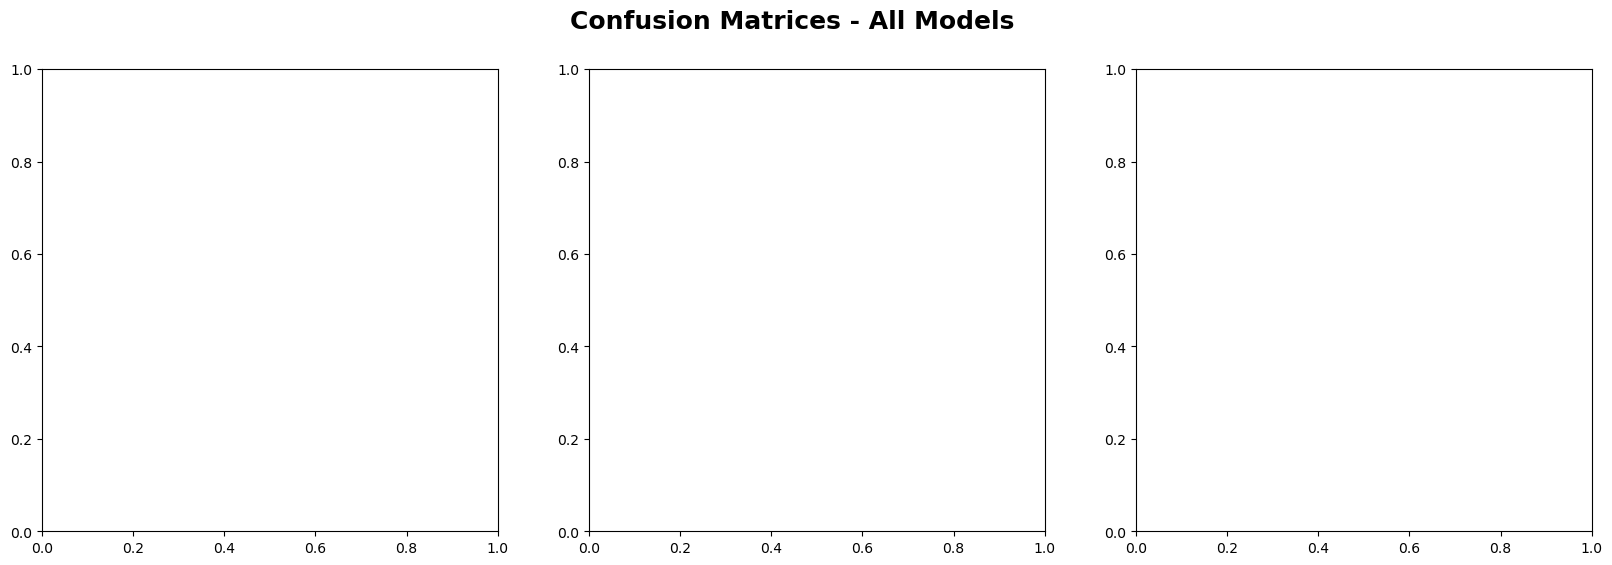

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices - All Models', fontsize=18, fontweight='bold')

for idx, results in enumerate(all_results):
    cm = confusion_matrix(y_test, results['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                ax=axes[idx], linewidths=0.5, square=True, annot_kws={"size": 14})
    axes[idx].set_title(f"{results['name']}\nAccuracy: {results['accuracy']*100:.2f}%", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 17. ROC Curves

In [ ]:
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'purple']

for results, color in zip(all_results, colors):
    fpr, tpr, _ = roc_curve(y_test, results['y_pred_prob'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f"{results['name']} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], color='gray', linewidth=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curves - Model Comparison', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 18. Model Comparison

In [5]:
model_names = [r['name'] for r in all_results]
metrics = {
    'Accuracy' : [r['accuracy']  * 100 for r in all_results],
    'Precision': [r['precision'] * 100 for r in all_results],
    'Recall'   : [r['recall']    * 100 for r in all_results],
    'F1-Score' : [r['f1']        * 100 for r in all_results]
}

x = np.arange(len(model_names))
width = 0.2
colors = ['blue', 'green', 'red', 'orange']

fig, ax = plt.subplots(figsize=(14, 7))
for i, (metric_name, values) in enumerate(metrics.items()):
    bars = ax.bar(x + i * width, values, width, label=metric_name, color=colors[i], edgecolor='black')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Models', fontsize=13)
ax.set_ylabel('Score (%)', fontsize=13)
ax.set_title('Model Comparison - All Metrics', fontsize=16, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim([70, 100])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print('-' * 65)
for r in all_results:
    print(f"{r['name']:<25} {r['accuracy']*100:>9.2f}% {r['precision']*100:>9.2f}% {r['recall']*100:>9.2f}% {r['f1']*100:>9.2f}%")

NameError: name 'all_results' is not defined

## 19. Predict on Custom Text

In [6]:
def predict_sentiment(text, model, tokenizer, model_name="Model", max_len=MAX_LEN):
    processed = preprocess_text(text)
    sequence  = tokenizer.texts_to_sequences([processed['processed_text']])
    padded    = pad_sequences(sequence, maxlen=max_len, padding='post', truncating='post')
    prediction = model.predict(padded, verbose=0)[0][0]
    sentiment  = "POSITIVE" if prediction > 0.5 else "NEGATIVE"
    confidence = prediction if prediction > 0.5 else 1 - prediction
    print(f"Text       : {text[:80]}")
    print(f"Model      : {model_name}")
    print(f"Sentiment  : {sentiment}")
    print(f"Confidence : {confidence*100:.2f}%")
    print(f"Raw Score  : {prediction:.4f}")
    print('-' * 50)
    return sentiment, confidence

custom_reviews = [
    "This movie was absolutely amazing! The acting was superb and the story was captivating.",
    "Terrible movie. Waste of time and money. The plot made no sense and acting was awful.",
    "The film was okay, nothing special. Some parts were good but overall it was average.",
    "One of the best movies I have ever seen! Brilliant direction and outstanding performances.",
    "I fell asleep halfway through. Boring, predictable, and poorly made.",
    "A masterpiece of cinema! Every scene was beautifully crafted and emotionally powerful."
]

for review in custom_reviews:
    predict_sentiment(review, bilstm_model, tokenizer, "Bidirectional LSTM")

NameError: name 'MAX_LEN' is not defined

## 20. Word Embedding Visualization (PCA)

In [7]:
from sklearn.decomposition import PCA

embedding_weights = bilstm_model.layers[0].get_weights()[0]
print(f"Embedding Matrix Shape: {embedding_weights.shape}")

word_freq = sorted(tokenizer.word_index.items(), key=lambda x: x[1])[:100]
words = [w[0] for w in word_freq]
word_indices = [w[1] for w in word_freq]
word_vectors = embedding_weights[word_indices]

pca = PCA(n_components=2)
word_vectors_2d = pca.fit_transform(word_vectors)

plt.figure(figsize=(16, 12))
plt.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1], c='steelblue', alpha=0.6, s=50)
for i, word in enumerate(words[:50]):
    plt.annotate(word, xy=(word_vectors_2d[i, 0], word_vectors_2d[i, 1]), fontsize=9, alpha=0.8)

plt.title('Word Embedding Visualization (PCA)', fontsize=16, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('word_embeddings_pca.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'bilstm_model' is not defined

## 21. Save All Models

In [ ]:
import os
os.makedirs('saved_models', exist_ok=True)

rnn_model.save('saved_models/simple_rnn_model.keras')
lstm_model.save('saved_models/lstm_model.keras')
bilstm_model.save('saved_models/bidirectional_lstm_model.keras')

import pickle
with open('saved_models/tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
